<a href="https://colab.research.google.com/github/vitorlopes-design/IA_EQ/blob/main/aula01_exercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Aula 01 — Seu Primeiro Notebook: Dados de Processo no Python

**Disciplina:** Inteligência Artificial Aplicada à Engenharia Química  
**Dataset:** Coluna de destilação etanol-água — 24h de operação (amostragem a cada 30s)

---

## Contexto

Você é um **engenheiro de processos** na planta Química ABC. Recebeu um arquivo CSV com dados de 24h de operação de uma coluna de destilação de etanol-água. Sua missão é explorar esses dados para entender o comportamento da coluna.

## 3.1 — Exercício Guiado: Setup + Pandas Básico

Siga passo-a-passo as células abaixo. Execute cada uma com `Shift + Enter`.

### Passo 1: Importar as bibliotecas

In [ ]:
import pandas as pd
import numpy as np

### Passo 2: Carregar o dataset

> 💡 O CSV está hospedado no GitHub do repositório da disciplina.

In [ ]:
URL = "https://raw.githubusercontent.com/LuisGSVasconcelos/IA_EngQuimica/main/dados/aula01/coluna_destilacao_24h.csv"

df = pd.read_csv(URL)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"Colunas: {list(df.columns)}")

Dataset carregado: 2880 linhas, 7 colunas
Colunas: ['timestamp', 'T_top_C', 'T_base_C', 'P_coluna_kPa', 'F_alimentacao_kg_h', 'D_destilado_kg_h', 'B_residuo_kg_h']


### Passo 3: Primeiras 5 linhas — `df.head()`

In [ ]:
df.head()

,timestamp,T_top_C,T_base_C,P_coluna_kPa,F_alimentacao_kg_h,D_destilado_kg_h,B_residuo_kg_h
0,2026-08-12 08:00:00,78.2611,100.3812,111.1828,1007.2337,601.7617,405.4721
1,2026-08-12 08:00:30,78.3741,100.3565,110.3760,1001.6992,599.9282,401.7710
2,2026-08-12 08:01:00,78.3493,99.9758,111.4503,998.2129,598.5437,399.6692
3,2026-08-12 08:01:30,78.4312,99.5834,111.5643,1005.7821,600.4705,405.3116
4,2026-08-12 08:02:00,78.1939,99.7065,109.8294,998.9577,599.7868,399.1709


### Passo 4: Informações sobre o dataframe — `df.info()`

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           2880 non-null   object 
 1   T_top_C             2880 non-null   float64
 2   T_base_C            2879 non-null   float64
 3   P_coluna_kPa        2879 non-null   float64
 4   F_alimentacao_kg_h  2880 non-null   float64
 5   D_destilado_kg_h    2880 non-null   float64
 6   B_residuo_kg_h      2879 non-null   float64
dtypes: float64(6), object(1)
memory usage: 157.6+ KB


### Passo 5: Estatísticas descritivas — `df.describe()`

In [ ]:
df.describe()

,T_top_C,T_base_C,P_coluna_kPa,F_alimentacao_kg_h,D_destilado_kg_h,B_residuo_kg_h
count,2880.000000,2879.000000,2879.000000,2880.000000,2880.000000,2879.000000
mean,78.272848,100.076469,111.242244,988.789049,599.772975,389.012607
std,0.269722,0.495167,0.883597,38.916795,1.527882,37.993411
min,77.319100,98.538000,108.811000,840.950900,593.266300,245.043500
25%,78.090875,99.733600,110.679300,997.300725,598.989950,397.031900
50%,78.243050,100.050600,111.134200,999.635000,599.895800,399.556400
75%,78.406000,100.384300,111.629550,1001.852900,600.783025,401.986200
max,79.494400,101.859300,115.185700,1012.077500,603.840300,413.190600


### ✏️ Pausa reflexiva (2 min)

Anote abaixo **uma coisa nova** que você aprendeu sobre os dados dessa coluna:

> _Escreva aqui..._

---

## 3.2 — Exercício em Grupo: Interpretando os Dados da Planta

Agora que você carregou os dados, responda as perguntas abaixo com seu grupo.

### Pergunta 1: Correlação entre variáveis

Calcule a matriz de correlação entre as variáveis numéricas. Qual par de variáveis tem a maior correlação? Por que fisicamente elas se correlacionam?

In [ ]:
df_numeric = df.select_dtypes(include='number')
df_numeric.corr()

,T_top_C,T_base_C,P_coluna_kPa,F_alimentacao_kg_h,D_destilado_kg_h,B_residuo_kg_h
T_top_C,1.000000,0.308685,0.499272,-0.594410,-0.384435,-0.593496
T_base_C,0.308685,1.000000,0.687606,-0.413748,-0.248444,-0.414054
P_coluna_kPa,0.499272,0.687606,1.000000,-0.665634,-0.417437,-0.665375
F_alimentacao_kg_h,-0.594410,-0.413748,-0.665634,1.000000,0.620739,0.999503
D_destilado_kg_h,-0.384435,-0.248444,-0.417437,0.620739,1.000000,0.595848
B_residuo_kg_h,-0.593496,-0.414054,-0.665375,0.999503,0.595848,1.000000


### Pergunta 2: Visualização temporal

Gere um gráfico de `T_top_C` ao longo do tempo. O que você observa entre 14h e 16h?

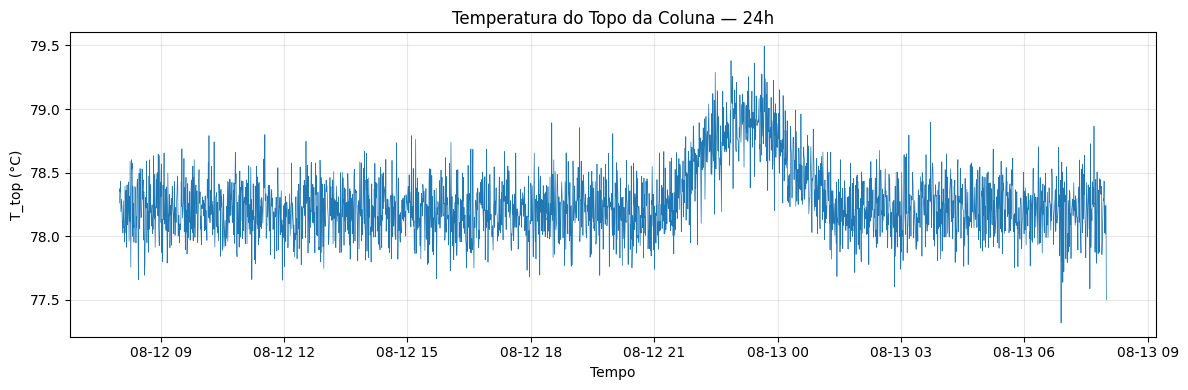

In [ ]:
import matplotlib.pyplot as plt
df['timestamp'] = pd.to_datetime(df['timestamp'])
plt.figure(figsize=(12, 4))
plt.plot(df['timestamp'], df['T_top_C'], linewidth=0.5)
plt.xlabel('Tempo')
plt.ylabel('T_top (°C)')
plt.title('Temperatura do Topo da Coluna — 24h')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Pergunta 3: Interpretação

Escreva 1 parágrafo respondendo: **"O que aconteceu na coluna entre 14h e 16h?"**

> _Escreva aqui sua interpretação..._
Dentre estes horários não há mudança, porém entre os horários de 21 ás 00 há um distubiu de tempetaruta
---

### 🧠 Desafio extra (opcional)

Se você quisesse estimar a composição do destilado a partir de `T_top_C` e `P_coluna_kPa`, que modelo simples você usaria? Quantos dados precisaria?

---

## Checklist de Verificação

- [x] `import pandas as pd` executou sem erro
- [x] `df.head()` mostrou as primeiras linhas
- [x] `df.describe()` calculou média, desvio, min, max
- [x] Identificou pelo menos 1 correlação interessante
- [x] Gerou gráfico de T_top ao longo do tempo
- [x] Escreveu interpretação em português